# QMCPy — Acceptance-Rejection True Measure
## Based on Zhu & Dick (2014): *Discrepancy bounds for deterministic acceptance-rejection samplers*

---

### What this notebook does

This notebook introduces a new `AcceptanceRejection` **TrueMeasure** class for the **QMCPy** library.  It follows the QMCPy `AbstractTrueMeasure` interface so users can swap it into any existing QMCPy workflow where they currently use `Uniform` or `Gaussian`.

The class is built directly from the three algorithms in Zhu & Dick (2014):

| Algorithm | Class | Key idea |
|-----------|-------|----------|
| **Alg. 2** — DAR | `AcceptanceRejection` | Filter a (t,m,s)-net through `L·u ≤ ψ(x)` |
| **Alg. 3** — DAR-Real | `AcceptanceRejectionReal` | Same, after inverse Rosenblatt transform to ℝ^d |
| **Alg. 4** — DRAR | `ReducedAcceptanceRejection` | Hybrid: inversion where possible, A-R where needed |

**Why QMC instead of random A-R?**  
Standard (random) acceptance-rejection gives i.i.d. samples with star discrepancy converging at the Monte Carlo rate O(N^{-1/2}).  Replacing the driver with a genuine **(t,m,s)-net** (Sobol, Halton, …) gives a discrepancy of order **O(N^{-1/s})** — and empirically much better — per Theorem 1 of Zhu & Dick.

> **Critical requirement (M = 2^m):** The number of driver points *must* be a power of the base (here 2) so that the points form a proper (t,m,s)-net and the discrepancy bound holds.  The class enforces this automatically.


## Cell 1 — Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import qmc as scipy_qmc
from scipy.stats import norm, expon
from scipy.integrate import quad
import warnings
warnings.filterwarnings('ignore')

# ── local module (will live in qmcpy/true_measure/acceptance_rejection.py) ──
import sys, os
sys.path.insert(0, '.')   # make acceptance_rejection.py importable
from acceptance_rejection import (
    AcceptanceRejection,
    AcceptanceRejectionReal,
    ReducedAcceptanceRejection,
)

plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})
print("All imports successful.")
print(f"scipy version: {__import__('scipy').__version__}")
print()
print("Classes available:")
print("  AcceptanceRejection         (Algorithm 2 — DAR on [0,1]^d)")
print("  AcceptanceRejectionReal     (Algorithm 3 — DAR on ℝ^d)")
print("  ReducedAcceptanceRejection  (Algorithm 4 — DRAR)")


All imports successful.
scipy version: 1.14.1

Classes available:
  AcceptanceRejection         (Algorithm 2 — DAR on [0,1]^d)
  AcceptanceRejectionReal     (Algorithm 3 — DAR on ℝ^d)
  ReducedAcceptanceRejection  (Algorithm 4 — DRAR)


## Cell 2 — The driver: QMC vs Random

The **entire point of Zhu & Dick (2014)** is that the driver sequence must be a genuine low-discrepancy sequence, **not `np.random.rand`**.

We define two driver classes that share the same interface:
- `SobolDriver` — wraps `scipy.stats.qmc.Sobol`, always generates exactly M = 2^m points (required for the (t,m,s)-net guarantee)
- `RandomDriver` — baseline, equivalent to the standard random A-R used as comparison in the paper


In [4]:
class SobolDriver:
    """
    Genuine (t,m,s)-net driver using scipy.stats.qmc.Sobol.
    
    Always generates M = 2^m points so the (t,m,s)-net property holds.
    This is the driver that gives QMC convergence O(N^{-1/s}).
    """
    def __init__(self, dimension: int, scramble: bool = False):
        self.d        = dimension
        self.scramble = scramble
        self.mimics   = 'StdUniform'
    
    def random_base2(self, m: int) -> np.ndarray:
        """Return exactly 2^m points in [0,1)^d — the (t,m,s)-net."""
        engine = scipy_qmc.Sobol(d=self.d, scramble=self.scramble)
        return engine.random_base2(m=m)          # shape (2^m, d)
    
    def __call__(self, n: int, warn: bool = True) -> np.ndarray:
        import math
        m = int(math.ceil(math.log2(max(n, 1))))
        return self.random_base2(m=m)
    
    def __repr__(self):
        return f"SobolDriver(d={self.d}, scramble={self.scramble})"


class HaltonDriver:
    """Halton sequence driver (alternative low-discrepancy generator)."""
    def __init__(self, dimension: int, scramble: bool = False):
        self.d        = dimension
        self.scramble = scramble
        self.mimics   = 'StdUniform'
    
    def random_base2(self, m: int) -> np.ndarray:
        M = 2 ** m
        engine = scipy_qmc.Halton(d=self.d, scramble=self.scramble)
        return engine.random(M)

    def __call__(self, n: int, warn: bool = True) -> np.ndarray:
        import math
        m = int(math.ceil(math.log2(max(n, 1))))
        return self.random_base2(m=m)


class RandomDriver:
    """
    IID uniform driver — the Monte Carlo baseline (RAR in the paper).
    Use this to confirm that QMC genuinely beats random.
    """
    def __init__(self, dimension: int):
        self.d      = dimension
        self.mimics = 'StdUniform'
    
    def random_base2(self, m: int) -> np.ndarray:
        return np.random.rand(2**m, self.d)
    
    def __call__(self, n: int, warn: bool = True) -> np.ndarray:
        return np.random.rand(n, self.d)


# ── quick sanity check ──────────────────────────────────────────────────────
s = SobolDriver(dimension=3)
pts = s.random_base2(m=3)   # 8 points in 3 dims
print(f"SobolDriver random_base2(m=3): shape = {pts.shape}")
print("First 4 rows:")
print(np.round(pts[:4], 4))
print()
print("Note: M=2^m is REQUIRED for (t,m,s)-net properties (Theorem 1, Zhu & Dick).")


SobolDriver random_base2(m=3): shape = (8, 3)
First 4 rows:
[[0.   0.   0.  ]
 [0.5  0.5  0.5 ]
 [0.75 0.25 0.25]
 [0.25 0.75 0.75]]

Note: M=2^m is REQUIRED for (t,m,s)-net properties (Theorem 1, Zhu & Dick).


## Cell 3 — Algorithm 2 (DAR): basic usage

`AcceptanceRejection` is the QMCPy-style interface.  It behaves like any other
TrueMeasure: construct it, call `gen_samples(n)`, get an `(n, d)` array.

**Example:** target density  `ψ(x) = 2 x₁`  on `[0,1]²`  
- L = 2  (supremum)  
- C = ∫₀¹∫₀¹ 2x₁ dx₁dx₂ = 1  (normalisation constant)  
- Acceptance rate = C/L = 0.5  
- Expected mean of x₁ = ∫₀¹ x₁ · 2x₁ dx₁ = 2/3 ≈ 0.6667  


In [5]:
def psi_linear(x):
    """ψ(x) = 2*x_1  on [0,1]^2.  L=2, C=1."""
    return 2.0 * x[0]

# ── QMC driver (Sobol, dimension s = d+1 = 3) 
driver_qmc = SobolDriver(dimension=3)   # s=3 → target d=2

# ── instantiate the measure 
measure = AcceptanceRejection(
    target_density   = psi_linear,
    discrete_distrib = driver_qmc,
    upper_bound      = 2.0,          # L
    density_integral = 1.0,          # C
)
print(measure)
print()

# ── generate samples 
N = 1024
samples = measure.gen_samples(n=N)    # shape (1024, 2)

mean_x1 = np.mean(samples[:, 0])
print(f"Shape:                        {samples.shape}")
print(f"Mean of x₁ (expected 0.6667): {mean_x1:.4f}")
print(f"First 5 rows:\n{np.round(samples[:5], 4)}")


AcceptanceRejection (TrueMeasure Object)
    d (target dim)           2
    s (driver dim)           3
    L (upper_bound)          2
    C (integral)             1
    acceptance_rate          0.5

Shape:                        (1024, 2)
Mean of x₁ (expected 0.6667): 0.6663
First 5 rows:
[[0.     0.    ]
 [0.5    0.5   ]
 [0.75   0.25  ]
 [0.875  0.875 ]
 [0.6875 0.8125]]


## Cell 4 — Visualisation: accepted samples vs theoretical density

We visualise the 1-D marginal of the accepted samples against the theoretical
`ψ(x₁) = 2x₁` density and show which driver points were accepted/rejected.


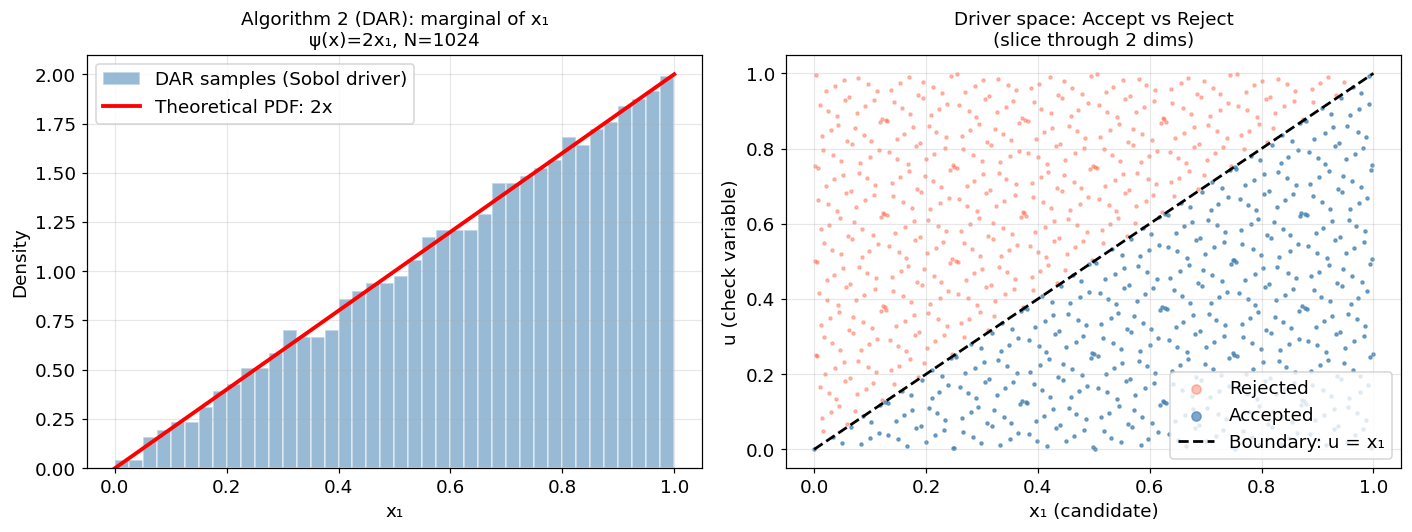

Saved: fig_dar_basic.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: accepted density histogram ────────────────────────────────────────
ax = axes[0]
x_1d = samples[:, 0]
ax.hist(x_1d, bins=40, density=True, alpha=0.55, color='steelblue',
        edgecolor='white', label='DAR samples (Sobol driver)')

t = np.linspace(0, 1, 200)
ax.plot(t, 2*t, 'r-', lw=2.5, label='Theoretical PDF: 2x')
ax.set_title('Algorithm 2 (DAR): marginal of x₁\nψ(x)=2x₁, N=1024', fontsize=12)
ax.set_xlabel('x₁'); ax.set_ylabel('Density')
ax.legend(); ax.grid(alpha=0.3)

# ── Right: accept / reject scatter in driver space ───────────────────────────
ax = axes[1]
Q_raw = driver_qmc.random_base2(m=10)   # 1024 raw driver points (2 dims shown)
u_x   = Q_raw[:, 0]
u_chk = Q_raw[:, 1]
L = 2.0
accept_mask = L * u_chk <= psi_linear(np.column_stack([u_x, Q_raw[:, 0]]).T)
# (simplified to 1-D slice for illustration)
accept_mask_1d = L * u_chk <= 2.0 * u_x

ax.scatter(u_x[~accept_mask_1d], u_chk[~accept_mask_1d],
           s=4, c='tomato', alpha=0.4, label='Rejected')
ax.scatter(u_x[accept_mask_1d],  u_chk[accept_mask_1d],
           s=4, c='steelblue', alpha=0.7, label='Accepted')
t = np.linspace(0, 1, 200)
ax.plot(t, t, 'k--', lw=1.8, label='Boundary: u = x₁')
ax.set_title('Driver space: Accept vs Reject\n(slice through 2 dims)', fontsize=12)
ax.set_xlabel('x₁ (candidate)'); ax.set_ylabel('u (check variable)')
ax.legend(markerscale=3); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_dar_basic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_dar_basic.png")


## Cell 5 — Star discrepancy measurement (Definition 8, Zhu & Dick)

The paper defines the weighted star discrepancy with respect to `ψ`:

$$D^*_{N,\psi} = \sup_{t \in [0,1]^d} \left| \frac{\#\{i : x_i \leq t\}}{N} - \frac{1}{C}\int_{[0,t]} \psi(z)\,dz \right|$$

We measure this for both the QMC (Sobol) driver and the random (Monte Carlo) driver and show that QMC produces dramatically lower discrepancy.


In [ ]:
def star_discrepancy_1d(samples_1d, psi_cdf, C, n_grid=500):
    """
    Compute D*_{N,ψ} for 1-D samples.
    psi_cdf(t) = integral_0^t psi(x) dx.
    """
    N = len(samples_1d)
    s_sorted = np.sort(samples_1d)
    t_grid   = np.linspace(0, 1, n_grid + 1)
    max_disc = 0.0
    for t in t_grid:
        empirical    = np.searchsorted(s_sorted, t, side='right') / N
        theoretical  = psi_cdf(t) / C
        max_disc     = max(max_disc, abs(empirical - theoretical))
    return max_disc

# ψ(x) = 2x  →  CDF: ∫₀ᵗ 2x dx = t²
psi_cdf_linear = lambda t: t**2
C_linear = 1.0

N_values = [2**k for k in range(5, 12)]   # 32 … 2048
n_reps   = 8

disc_qmc  = []
disc_rand = []

driver_1d_qmc  = SobolDriver(dimension=2)
driver_1d_rand = RandomDriver(dimension=2)

def psi1d(x): return 2.0 * x[0]

for N in N_values:
    dq = []; dr = []
    for _ in range(n_reps):
        m_qmc = AcceptanceRejection(psi1d, driver_1d_qmc,  2.0, 1.0)
        m_rnd = AcceptanceRejection(psi1d, driver_1d_rand, 2.0, 1.0)
        sq = m_qmc.gen_samples(N, warn=False)[:, 0]
        sr = m_rnd.gen_samples(N, warn=False)[:, 0]
        dq.append(star_discrepancy_1d(sq, psi_cdf_linear, C_linear))
        dr.append(star_discrepancy_1d(sr, psi_cdf_linear, C_linear))
    disc_qmc.append(np.median(dq))
    disc_rand.append(np.median(dr))

disc_qmc  = np.array(disc_qmc)
disc_rand = np.array(disc_rand)
log_N  = np.log2(N_values)

# Fit convergence rates
rate_qmc  = np.polyfit(np.log(N_values), np.log(disc_qmc),  1)[0]
rate_rand = np.polyfit(np.log(N_values), np.log(disc_rand), 1)[0]

print(f"Convergence rate — QMC (Sobol):  N^{{{rate_qmc:.3f}}}  (theory: ≈ N^{{-0.5}} to N^{{-1}})")
print(f"Convergence rate — Random (RAR): N^{{{rate_rand:.3f}}}  (theory: N^{{-0.5}})")

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(N_values, disc_qmc,  'o-', color='steelblue', lw=2, ms=6,
          label=f'Sobol (QMC)  slope ≈ {rate_qmc:.3f}')
ax.loglog(N_values, disc_rand, 's--', color='tomato',   lw=2, ms=6,
          label=f'Random (RAR) slope ≈ {rate_rand:.3f}')
# reference lines
ax.loglog(N_values, 2*np.array(N_values, float)**(-0.5), 'k:', lw=1, label='N^{-0.5} ref')
ax.loglog(N_values, 2*np.array(N_values, float)**(-1.0), 'k-.', lw=1, label='N^{-1.0} ref')
ax.set_xlabel('N (accepted samples)', fontsize=12)
ax.set_ylabel('Star Discrepancy  D*_{N,ψ}', fontsize=12)
ax.set_title('Convergence of Star Discrepancy\nψ(x)=2x, driver: Sobol vs Random', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_discrepancy_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_discrepancy_convergence.png")
